# Storytelling with: Data: สถิติการเกิดอัคคีภัยในประเทศไทย ปีพ.ศ. 2562
> ## โค้ดชุดนี้ถูกเขียนขึ้นมาเพื่อส่งเข้าร่วม โครงงาน Super AI Engineer Season 6 จัดขึ้นโดย สมาคมปัญญาประดิษฐ์ประเทศไทย (19/March/2026)
Dataset source: https://www.thackle.or.th/api/v1/file/download/datatset/26



---


## Section
- Setup & Load Data
- Exploratory Data Analysis (EDA เบื้องต้น)
- Data Cleansing & Preprocessing
- Advanced EDA & Insights
- Proposed Mitigation Strategies

# **1. Setup & Load Data**

### 1.1 Setup Libraries

ในการทำ Data Storytelling มีการใช้เครื่องมือดังนี้:

*   **Pandas & NumPy**: การจัดการข้อมูล (Data Manipulation) และการคำนวณเชิงตัวเลข
*   **Matplotlib & Seaborn**: ใช้สำหรับสร้างกราฟสถิติแบบ Static
*   **Plotly**: ใช้สร้าง Interactive Visualization ที่ผู้ใช้งานสามารถเอาเมาส์ไปชี้เพื่อดูรายละเอียด (Hover) หรือซูมดูข้อมูลเฉพาะจุดได้
*   **OS**: ใช้สำหรับการจัดการกับระบบไฟล์ (File System) Path ของไฟล์
*   **Warnings**: ใช้สำหรับซ่อนข้อความแจ้งเตือนที่ไม่จำเป็นเพื่อให้ Notebook ดูสะอาดและอ่านง่าย
*   **Thai Font Configuration**: การตั้งค่าฟอนต์ `TH Sarabun New` เพื่อให้กราฟสามารถแสดงผลภาษาไทยได้อย่างถูกต้องและสวยงาม

In [107]:
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
import os

# Filter warnings
warnings.filterwarnings('ignore')

# Install Plotly dependencies
!pip install plotly kaleido -q

# Check if Thai Font exists, if not, download it
font_path = 'thsarabunnew-webfont.ttf'
if not os.path.exists(font_path):
    print('Downloading Thai Font...')
    !wget -q https://github.com/Phonbopit/sarabun-webfont/raw/master/fonts/thsarabunnew-webfont.ttf
else:
    print('Thai Font already exists. Skipping download.')

# Configure font in Matplotlib and Seaborn
mpl.font_manager.fontManager.addfont(font_path)
mpl.rc('font', family='TH Sarabun New', size=16)
sns.set_theme(style="whitegrid", font="TH Sarabun New")

# Set global visualization settings
plt.rcParams['figure.dpi'] = 120

print('Import and Configuration Successfully')

Thai Font already exists. Skipping download.
Import and Configuration Successfully


### 1.2 Uploading and Reading the data

ในขั้นตอนนี้เราทำการโหลดข้อมูลจากไฟล์ CSV เข้าสู่ระบบเพื่อเตรียมพร้อมสำหรับการวิเคราะห์:

*   **Encoding ('utf-8-sig')**: ใช้เพื่อรองรับอักขระภาษาไทยและจัดการปัญหา BOM (Byte Order Mark) ที่มักพบในไฟล์จากระบบราชการไทย
*   **Data Inspection**: ตรวจสอบขนาดของข้อมูล (Shape) และรายชื่อคอลัมน์เพื่อให้เห็นภาพรวมเบื้องต้นของ Dataset
*   **Data Preview**: แสดงตัวอย่างข้อมูล 3 แถวแรกด้วยคำสั่ง `head()` เพื่อตรวจสอบความถูกต้องของข้อมูลในแต่ละคอลัมน์ก่อนเริ่มทำ EDA

In [108]:
# Define file path
file_path = '/content/conflagration.csv'

try:
    # Load fire statistics data
    df = pd.read_csv(file_path, encoding='utf-8-sig')

    print('-' * 60)
    print('Thailand Fire Statistics Data Loaded Successfully')
    print(f'   - Rows: {df.shape[0]:,d} | Columns: {df.shape[1]}')
    print(f'   - Column Names: {df.columns.tolist()}')
    print('-' * 60)

    # Display all rows to see the full picture of the dataset
    print(f'Total records in dataset: {len(df)} rows')
    pd.set_option('display.max_rows', None)  # Set pandas to show all rows
    display(df.head())
    pd.reset_option('display.max_rows') # Reset back to default

except FileNotFoundError:
    print(f"Error: The file at {file_path} was not found.")
    print("Please ensure you have uploaded 'conflagration.csv' to the /content/ folder.")
except Exception as e:
    print(f"An unexpected error occurred: {e}")

------------------------------------------------------------
Thailand Fire Statistics Data Loaded Successfully
   - Rows: 72 | Columns: 34
   - Column Names: ['province', 'event_count', 'district', 'subdistrict_count', 'village_count', 'local_admin_count', 'community_count', 'population', 'households', 'fatalities_count', 'injuries_count', 'firefighter_injuries', 'firefighter_fatalities', 'total_home_loss', 'partial_home_loss', 'commercial_buildings', 'high_rise_buildings', 'factories', 'hotels', 'farm_buildings', 'agricultural_land', 'department_stores', 'rice_mills', 'warehouses', 'shops', 'buildings', 'temporary_shelter', 'landfill_area', 'vehicles', 'religious_buildings', 'schools', 'government_offices', 'others', 'property_damage_cost']
------------------------------------------------------------
Total records in dataset: 72 rows


,province,event_count,district,subdistrict_count,village_count,local_admin_count,community_count,population,households,fatalities_count,...,shops,buildings,temporary_shelter,landfill_area,vehicles,religious_buildings,schools,government_offices,others,property_damage_cost
0,จังหวัด,จำนวนครั้ง,อำเภอ,จำนวนตำบล,จำนวนหมู่บ้าน,จำนวนอปท.,จำนวนชุมชน,ราษฎร(คน),ราษฎร(ครัวเรือน),ราษฎรเสียชีวิต(คน),...,ร้านค้า (หลัง),อาคาร/สิ่งก่อสร้าง,ที่พักชั่วคราว (แห่ง),บ่อขยะ (ไร่),ยานยนต์(คัน),ศาสนสถาน(แห่ง),โรงเรียน(แห่ง),สถานที่ราชการ(แห่ง),อื่นๆ,มูลค่าความเสียหายด้านทรัพย์สินของราษฎร(บาท)
1,กระบี่,3,2,5,7,-,-,4,4,-,...,-,-,-,-,-,-,-,1,-,-
2,กาญจนบุรี,7,7,7,5,-,-,64,38,-,...,-,-,-,-,-,-,-,-,-,"6,738,000"
3,กาฬสินธุ์,40,14,30,40,1,1,182,55,1,...,-,-,1,-,10,1,-,-,2,"12,973,690"
4,ขอนแก่น,28,13,25,30,-,-,95,32,-,...,-,-,-,-,-,-,-,3,2,"6,243,886"


# **2. Exploratory Data Analysis (EDA เบื้องต้น)**


### 2.1 Data Profiling & Missing Value Analysis:

> ขั้นตอน Exploratory Data Analysis (EDA) ในเฟสนี้ ออกแบบมาเพื่อทำ Data Profiling สำรวจ โครงสร้างและความถูกต้องของชุดข้อมูล มุ่งเน้นไปที่การนับจำนวนค่าว่างในทุกคอลัมน์
เราสามารถแสกนหา Missing value ได้ผ่านขั้นตอนดังต่อไปนี้:

1.  **การกรองข้อมูล (Data Filtration)**: เราทำการกรองแถวที่ไม่ใช่ข้อมูลจริงออก เช่น หัวตาราง, ท้ายตารางสรุปผล

2.  **การตรวจจับค่าว่างแบบ 2 ชั้น (Dual-Type Missing Value Detection)**:
    *   **ค่าว่างปกติ (Standard Nulls หรือ NaN)**
    *   **ค่าว่างซ่อนรูป (Hidden Nulls หรือ '-'**
    * ตรวจพบว่ามีการใช้เครื่องหมาย `-` เพื่อแทนค่าข้อมูลที่ไม่มีการรายงานหรือมีค่าเป็นศูนย์ เราจึงนำค่าว่างทั้ง 2 รูปแบบนี้มารวมกันเพื่อประเมิน **"เปอร์เซ็นต์ข้อมูลที่หายไปที่แท้จริง" (True Missing Percentage)**

3.  **การจัดลำดับความสำคัญผ่านกราฟ (Prioritization Visualization)**: เลือกใช้กราฟแท่งแนวนอน (Horizontal Bar Chart) โดยเรียงลำดับจากเปอร์เซ็นต์ข้อมูลที่หายไปมากที่สุดไปหาน้อยที่สุด วิธีนี้ช่วยให้เราเห็นได้ทันทีว่าตัวแปรใด ที่มีความน่าเชื่อถือของข้อมูลต่ำสุด ซึ่งจะช่วยประกอบการตัดสินใจในขั้นต่อไปว่า ควรจะตัดคอลัมน์ใดทิ้ง หรือคอลัมน์ใดที่ต้องระมัดระวังเป็นพิเศษในการนำไปวิเคราะห์ต่อ

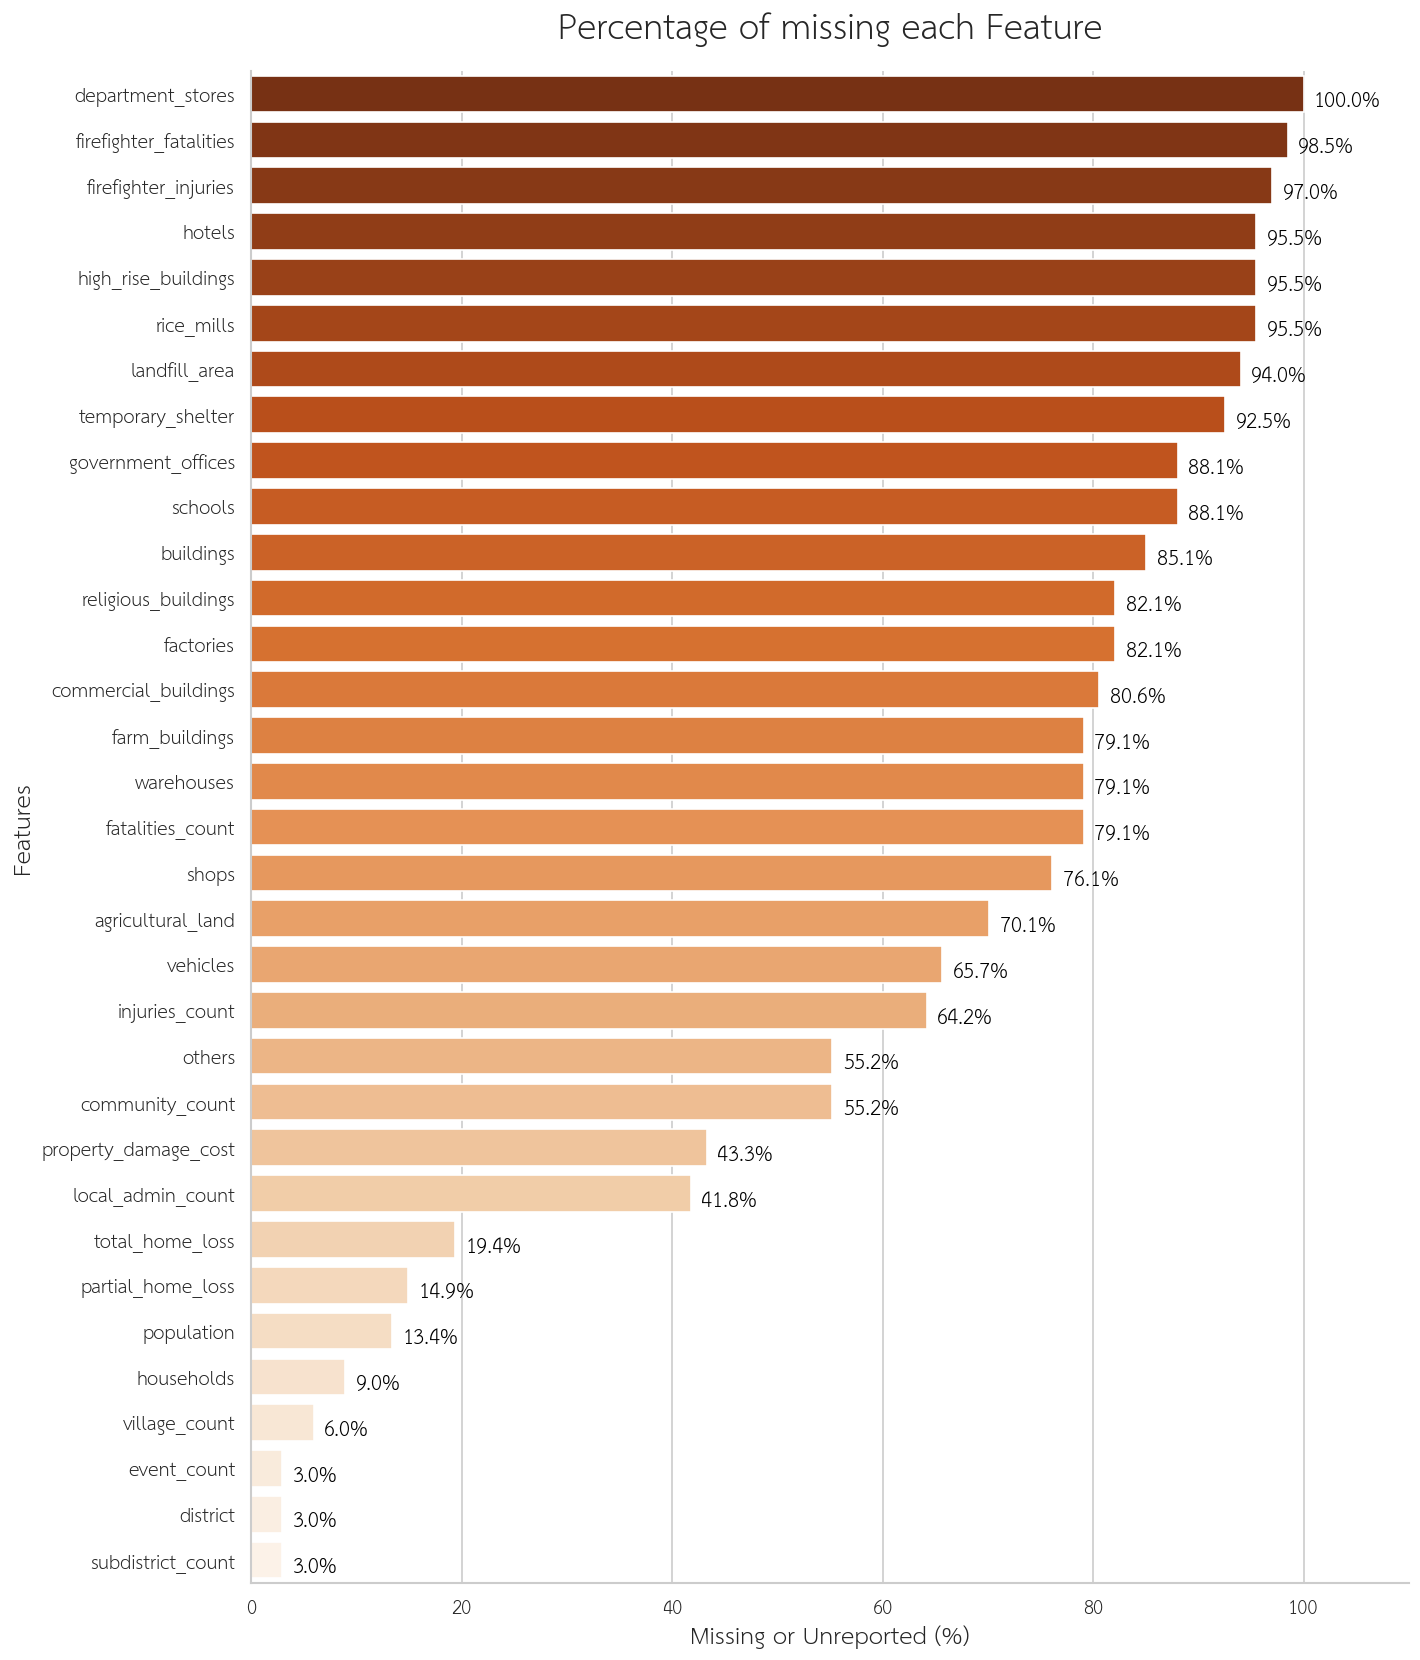


NATIONAL SUMMARY TABLE:


,province,event_count,district,subdistrict_count,village_count,local_admin_count,community_count,population,households,fatalities_count,...,shops,buildings,temporary_shelter,landfill_area,vehicles,religious_buildings,schools,government_offices,others,property_damage_cost
66,รวมทั้งหมด 65 จังหวัด,"1,479",432,896,"1,147",320,157,"9,576","4,979",20,...,64,19,8,31,102,16,9,15,478,"477,339,662"



DETAILED SUMMARY STATISTICS:
----------------------------------------
➜ event_count               : 1,479
➜ district                  : 432
➜ subdistrict_count         : 896
➜ village_count             : 1,147
➜ local_admin_count         : 320
➜ community_count           : 157
➜ population                : 9,576
➜ households                : 4,979
➜ fatalities_count          : 20
➜ injuries_count            : 104
➜ firefighter_injuries      : 3
➜ firefighter_fatalities    : 1
➜ total_home_loss           : 620
➜ partial_home_loss         : 535
➜ commercial_buildings      : 30
➜ high_rise_buildings       : 3
➜ factories                 : 30
➜ hotels                    : 3
➜ farm_buildings            : 42
➜ agricultural_land         : 2,602
➜ department_stores         : 0 (No data reported)
➜ rice_mills                : 3
➜ warehouses                : 22
➜ shops                     : 64
➜ buildings                 : 19
➜ temporary_shelter         : 8
➜ landfill_area             : 31
➜ ve

In [109]:
# 1. Prepare data for EDA (Clean garbage rows from the existing 'df')
df_eda = df.iloc[1:].copy()
# Filter out summary rows and metadata rows using keywords
df_eda = df_eda[~df_eda['province'].str.contains('รวม|ศูนย์|ข้อมูล|กรม', na=False)]

# 2. Calculate both '-' (Hidden Nulls) and actual NaN values
columns_to_check = df_eda.columns[1:]
missing_stats = []
total_rows = len(df_eda)

for col in columns_to_check:
    # Count both '-' and standard NaN values
    dash_count = (df_eda[col].astype(str).str.strip() == '-').sum()
    nan_count = df_eda[col].isna().sum()
    total_missing = dash_count + nan_count

    missing_pct = (total_missing / total_rows) * 100
    missing_stats.append({'Feature': col, 'Missing_Pct': missing_pct})

df_missing = pd.DataFrame(missing_stats).sort_values('Missing_Pct', ascending=False)

# 3. Visualization
plt.figure(figsize=(12, 14))
sns.set_theme(style="whitegrid", font="TH Sarabun New")

# Create Barplot
ax = sns.barplot(
    x='Missing_Pct',
    y='Feature',
    data=df_missing,
    palette='Oranges_r',
    orient='h'
)

# Add percentage text
for p in ax.patches:
    width = p.get_width()
    if width >= 0:
        ax.text(width + 1,
                p.get_y() + p.get_height() / 2. + 0.15,
                f'{width:.1f}%',
                ha="left", va="center", fontsize=12, color='black')

# Chart Styling
plt.title('Percentage of missing each Feature', fontsize=20, fontweight='bold', pad=20)
plt.xlabel('Missing or Unreported (%)', fontsize=14)
plt.ylabel('Features', fontsize=14)
plt.xlim(0, 110)
sns.despine()
plt.tight_layout()
plt.show()

# 4. Extract and Display Summary Row for all columns
print('\n' + '='*80)
summary_row = df[df['province'].str.contains('รวมทั้งหมด', na=False)]

if not summary_row.empty:
    print("NATIONAL SUMMARY TABLE:")
    display(summary_row)

    print("\nDETAILED SUMMARY STATISTICS:")
    print("-" * 40)

    # Iterate through columns (skip 'province' which is text)
    for col in summary_row.columns[1:]:
        val = str(summary_row[col].values[0]).strip()

        # Clean value for printing (handle commas and dashes)
        clean_val = val.replace(',', '')
        if clean_val == '-' or clean_val == 'nan' or clean_val == '':
            print(f"➜ {col:<25} : 0 (No data reported)")
        else:
            try:
                # Try to format as integer for readability
                num_val = float(clean_val)
                print(f"➜ {col:<25} : {num_val:,.0f}")
            except ValueError:
                print(f"➜ {col:<25} : {val}")
    print("-" * 40)
else:
    print('Could not find the summary row in the dataset.')

# **3  Data Cleansing & Preprocessing**

### 3.1 Data Pipeline & Strategic Feature Engineering

ในการเปลี่ยนข้อมูลดิบ (Raw Data) ให้กลายเป็นข้อมูลที่พร้อมสำหรับการวิเคราะห์เชิงลึก เราได้วาง Pipeline การจัดการข้อมูลออกเป็น 4 ขั้นตอนหลัก เพื่อปิดรอยรั่วทางสถิติที่ตรวจพบในรอบ EDA:

**1. Row Filtering (การคัดกรองแถว)**
* ดำเนินการตัด "ข้อมูลรบกวน" ออกจากชุดข้อมูล เช่น แถวหัวตารางที่เป็นคำอธิบายภาษาไทย, แถวสรุปผลรวมระดับประเทศ (National Summary), และแถวระบุวันที่อัปเดตข้อมูล
* เพื่อให้เหลือเฉพาะข้อมูล "ระดับจังหวัด" ที่เป็นหน่วยวิเคราะห์หลัก (Unit of Analysis) ที่แท้จริง

**2. Feature Dropping (การกำจัดตัวแปรที่ไร้นัยสำคัญ)**
* ทำการตรวจสอบทุกคอลัมน์เพื่อหา Zero-variance predictors หรือคอลัมน์ที่มีแต่ค่าว่าง (เครื่องหมาย - หรือ NaN) เต็ม 100%
* ตัวแปรที่ไม่มีความผันแปรของข้อมูลจะถูกลบทิ้งเพื่อลดความซับซ้อน (Complexity) ของโมเดล

**3. Data Standardization & Casting (การปรับมาตรฐานและแปลงชนิดข้อมูล)**
* **Data Cleaning**: แทนที่เครื่องหมาย '-' ด้วยเลข 0 ตามบริบทของชุดข้อมูล (หมายถึงไม่มีเหตุการณ์เกิดขึ้น)
* **Formatting**: กำจัดเครื่องหมายลูกน้ำ (,) และช่องว่าง (Whitespace) ที่ปนมากับตัวเลข
* **Type Casting**: บังคับเปลี่ยนชนิดข้อมูลให้เป็น Numeric ทั้งหมดเพื่อให้รองรับการคำนวณทางสถิติและการวิเคราะห์ค่าสหสัมพันธ์ (Correlation)

**4. Strategic Feature Engineering (การสกัดฟีเจอร์เชิงกลยุทธ์)**
นี่คือขั้นตอนสำคัญในการเพิ่มประสิทธิภาพของตัวแปรและแก้ปัญหา Multicollinearity ในกลุ่มข้อมูลที่อยู่อาศัย:
* **Consolidation (การยุบรวม)**: รวม `total_home_loss` และ `partial_home_loss` เข้าด้วยกันเป็น `home_loss_total` เพื่อป้องกันการนับซ้ำ (Double Counting) และ Group กลุ่มของบ้านที่อยู่อาศัยให้อยู่รวมกัน
* **Feature Extraction (การสกัดดัชนีใหม่)**: สร้างตัวแปร `home_severity_ratio` เพื่อวัด "ความรุนแรงเชิงคุณภาพ" โดยคำนวณสัดส่วนบ้านที่เสียหายทั้งหลังต่อจำนวนบ้านที่ประสบเหตุทั้งหมด เพื่อใช้เป็นตัวแปรสำคัญ (Predictor) ในการบ่งชี้ระดับหายนะที่แม่นยำกว่าการนับจำนวนเพียงอย่างเดียว

In [115]:
print("(Cleaning Log)\n" + "="*50)

# Start cleaning from the original df
df_clean = df.copy()

# Log 1: Remove Irrelevant Rows (Thai Headers, Nulls, and Footers)
df_clean = df_clean.iloc[1:]
rows_before = len(df_clean)
df_clean = df_clean.dropna(subset=['province'])
df_clean = df_clean[~df_clean['province'].astype(str).str.contains('รวม|ศูนย์|ข้อมูล|กรม', na=False)]
rows_after = len(df_clean)

print(f"- Log 1: Removed garbage rows (From {rows_before} rows to {rows_after} actual provinces)")

# Log 2: Scan and Drop Features (Columns) with 100% Missing Data
cols_to_drop = []
total_rows = len(df_clean)
cols_before = df_clean.shape[1]

for col in df_clean.columns[1:]:
    missing_count = (df_clean[col].astype(str).str.strip() == '-').sum() + df_clean[col].isnull().sum()
    if missing_count == total_rows:
        cols_to_drop.append(col)

if len(cols_to_drop) > 0:
    df_clean = df_clean.drop(columns=cols_to_drop)
    print(f"- Log 2: Dropped {len(cols_to_drop)} columns with 100% missing data")
else:
    print("- Log 2: No 100% missing features found.")

# Log 3: Handle Dashes, Commas, and Type Casting
cols_to_convert = df_clean.columns[1:]

for col in cols_to_convert:
    df_clean[col] = df_clean[col].astype(str).str.replace(',', '', regex=False).str.strip().replace('-', '0')
    df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce').fillna(0)

df_clean['province'] = df_clean['province'].str.strip()

print(f"- Log 3: Converted '-' to 0, removed commas, and casted data types to Numeric.")

# Log 4: Feature Engineering (Handling Multicollinearity & Severity Ratio)
if 'total_home_loss' in df_clean.columns and 'partial_home_loss' in df_clean.columns:
    # 1. Consolidate home loss quantity
    df_clean['home_loss_total'] = df_clean['total_home_loss'] + df_clean['partial_home_loss']

    # 2. Extract Intensity Proxy (Severity Ratio)
    df_clean['home_severity_ratio'] = np.where(
        df_clean['home_loss_total'] > 0,
        df_clean['total_home_loss'] / df_clean['home_loss_total'],
        0
    )

    # 3. Drop original residential columns to mitigate multicollinearity
    df_clean = df_clean.drop(columns=['total_home_loss', 'partial_home_loss'])

    print(f"- Log 4: Feature Engineering completed. Merged home loss data and created 'home_severity_ratio'.")
    print("\n Data Cleaning Process Complete! Ready for analysis.")
else:
    print("⚠ Log 4: Required columns for Home Loss analysis not found. Skipping Log 4.")

# Summary of Data Shape
dropped_rows = rows_before - rows_after
dropped_cols = len(cols_to_drop)

print('-' * 80)
print(f"Raw records: {rows_before:>4} rows | {cols_before:>2} columns")
print('-' * 80)
print(f"- Final Shape: {df_clean.shape[0]:,d} Rows | {df_clean.shape[1]} Columns")
print('-' * 80)

(Cleaning Log)
- Log 1: Removed garbage rows (From 71 rows to 65 actual provinces)
- Log 2: Dropped 1 columns with 100% missing data
- Log 3: Converted '-' to 0, removed commas, and casted data types to Numeric.
- Log 4: Feature Engineering completed. Merged home loss data and created 'home_severity_ratio'.

 Data Cleaning Process Complete! Ready for analysis.
--------------------------------------------------------------------------------
Raw records:   71 rows | 34 columns
--------------------------------------------------------------------------------
- Final Shape: 65 Rows | 33 Columns
--------------------------------------------------------------------------------


### 3.2 Spatial Data Padding

ในการวิเคราะห์ข้อมูลเชิงพื้นที่ (Spatial Analysis) ความครบถ้วนของหน่วยทางภูมิศาสตร์เป็นสิ่งสำคัญมาก แต่จากการสำรวจในขั้นตอน EDA เราพบข้อจำกัดดังนี้:

*   **ข้อมูลไม่ครบถ้วน**: ประเทศไทยมีทั้งหมด 77 จังหวัด แต่ใน Dataset นี้มีการส่งรายงานมาเพียง 65 จังหวัดเท่านั้น
*   **การจัดการจังหวัดที่ขาดหาย**: เพื่อให้การแสดงผลบนแผนที่ (Choropleth Map) ไม่ดูโหว่หรือผิดเพี้ยน เราจึงทำการเพิ่มแถวข้อมูลสำหรับ 12 จังหวัดที่ขาดหายไปให้ครบตามมาตรฐาน
*   **การใช้ค่า NaN (Not a Number)**: เราเลือกแทนค่าในคอลัมน์ตัวเลขด้วย `NaN` แทนที่จะเป็น `0` เนื่องจากในทางสถิติ 'การไม่มีรายงาน' (No Data) แตกต่างจาก 'การรายงานว่าไม่มีเหตุการณ์เกิดขึ้น' (Zero Events) การใช้ `NaN` จะช่วยให้ Plotly แสดงผลพื้นที่เหล่านี้เป็นสีเทา (No Data) ซึ่งสื่อสารได้ถูกต้องตามความเป็นจริงมากกว่า

In [111]:
print("Starting Province Mapping Process\n" + "="*50)

# 1. Standard list of 77 provinces in Thailand
thai_77_provinces = [
    "กรุงเทพมหานคร", "กระบี่", "กาญจนบุรี", "กาฬสินธุ์", "กำแพงเพชร", "ขอนแก่น", "จันทบุรี", "ฉะเชิงเทรา", "ชลบุรี", "ชัยนาท",
    "ชัยภูมิ", "ชุมพร", "เชียงราย", "เชียงใหม่", "ตรัง", "ตราด", "ตาก", "นครนายก", "นครปฐม", "นครพนม", "นครราชสีมา",
    "นครศรีธรรมราช", "นครสวรรค์", "นนทบุรี", "นราธิวาส", "น่าน", "บึงกาฬ", "บุรีรัมย์", "ปทุมธานี", "ประจวบคีรีขันธ์",
    "ปราจีนบุรี", "ปัตตานี", "พระนครศรีอยุธยา", "พะเยา", "พังงา", "พัทลุง", "พิจิตร", "พิษณุโลก", "เพชรบุรี", "เพชรบูรณ์",
    "แพร่", "ภูเก็ต", "มหาสารคาม", "มุกดาหาร", "แม่ฮ่องสอน", "ยโสธร", "ยะลา", "ร้อยเอ็ด", "ระนอง", "ระยอง", "ราชบุรี",
    "ลพบุรี", "ลำปาง", "ลำพูน", "เลย", "ศรีสะเกษ", "สกลนคร", "สงขลา", "สตูล", "สมุทรปราการ", "สมุทรสงคราม", "สมุทรสาคร",
    "สระแก้ว", "สระบุรี", "สิงห์บุรี", "สุโขทัย", "สุพรรณบุรี", "สุราษฎร์ธานี", "สุรินทร์", "หนองคาย", "หนองบัวลำภู",
    "อ่างทอง", "อำนาจเจริญ", "อุดรธานี", "อุตรดิตถ์", "อุทัยธานี", "อุบลราชธานี"
]

# 2. Identify missing provinces
current_provinces = set(df_clean['province'])
missing_provinces = sorted(list(set(thai_77_provinces) - current_provinces))

print(f"Identified {len(missing_provinces)} provinces with no submitted reports:")
print(", ".join(missing_provinces))

# 3. Create placeholder rows with NaN for missing provinces
missing_rows = []
for prov in missing_provinces:
    row = {'province': prov}
    for col in df_clean.columns[1:]:
        row[col] = np.nan
    missing_rows.append(row)

df_missing_placeholders = pd.DataFrame(missing_rows)

# 4. Concatenate and Sort
df_mapped = pd.concat([df_clean, df_missing_placeholders], ignore_index=True)
df_mapped = df_mapped.sort_values('province').reset_index(drop=True)

print("\nMapping Complete: Structure updated to 77 provinces.")
print("-" * 60)
print(f"Final Dataset Shape: {df_mapped.shape[0]} Rows | {df_mapped.shape[1]} Columns")
print("-" * 60)

display(df_mapped.head(10))

Starting Province Mapping Process
Identified 12 provinces with no submitted reports:
กรุงเทพมหานคร, กำแพงเพชร, ชุมพร, นครนายก, ปราจีนบุรี, ภูเก็ต, ระนอง, ลพบุรี, สุราษฎร์ธานี, หนองคาย, อุทัยธานี, แม่ฮ่องสอน

Mapping Complete: Structure updated to 77 provinces.
------------------------------------------------------------
Final Dataset Shape: 77 Rows | 33 Columns
------------------------------------------------------------


,province,event_count,district,subdistrict_count,village_count,local_admin_count,community_count,population,households,fatalities_count,...,temporary_shelter,landfill_area,vehicles,religious_buildings,schools,government_offices,others,property_damage_cost,home_loss_total,home_severity_ratio
0,กระบี่,3.0,2.0,5.0,7.0,0.0,0.0,4.0,4.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.000000
1,กรุงเทพมหานคร,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,กาญจนบุรี,7.0,7.0,7.0,5.0,0.0,0.0,64.0,38.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,6738000.0,30.0,0.766667
3,กาฬสินธุ์,40.0,14.0,30.0,40.0,1.0,1.0,182.0,55.0,1.0,...,1.0,0.0,10.0,1.0,0.0,0.0,2.0,12973690.0,51.0,0.588235
4,กำแพงเพชร,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,ขอนแก่น,28.0,13.0,25.0,30.0,0.0,0.0,95.0,32.0,0.0,...,0.0,0.0,0.0,0.0,0.0,3.0,2.0,6243886.0,28.0,0.642857
6,จันทบุรี,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.000000
7,ฉะเชิงเทรา,15.0,7.0,14.0,15.0,0.0,0.0,67.0,17.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1155360.0,16.0,0.062500
8,ชลบุรี,56.0,8.0,32.0,38.0,0.0,0.0,82.0,44.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,6.0,177630000.0,29.0,0.379310
9,ชัยนาท,12.0,7.0,10.0,12.0,0.0,0.0,22.0,10.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,2.0,0.0,9.0,0.333333


# **4. Advanced EDA & Insights**

### 4.1 EDA & Insight: จังหวัดไหนเสี่ยงจริง? (True Risk Profile)

#### **Priority Score (Composite Index)**
การคำนวณ **Priority Score** เป็นการสร้างดัชนีชี้วัดโดยนำอันดับเปอร์เซ็นไทล์ของ 2 มิติหลักมาหาค่าเฉลี่ย:
*   **Event Rank**: อันดับความถี่ในการเกิดเหตุ
*   **Damage Rank**: อันดับมูลค่าความเสียหาย
*   **สูตรการคำนวณ**: `(Event Rank + Damage Rank) / 2`

> ผลลัพธ์คือ **"คะแนนความเสี่ยงรวม (0-100)"** เพียงค่าเดียว ซึ่งช่วยให้ผู้บริหารสามารถจัดลำดับความสำคัญ (Ranking) และตัดสินใจจัดสรรงบประมาณได้อย่างแม่นยำ

---

In [112]:
# -------------------------------------------------------------------------
# 1. Pipeline Synchronization & Feature Engineering
# -------------------------------------------------------------------------
df_insight = df_clean.copy()

# Calculate relative metrics
df_insight['frequency_rank'] = df_insight['event_count'].rank(pct=True) * 100
df_insight['damage_rank']    = df_insight['property_damage_cost'].rank(pct=True) * 100
df_insight['priority_index'] = (df_insight['frequency_rank'] + df_insight['damage_rank']) / 2

# Exclude observations with no variance (Zero events)
df_insight = df_insight[df_insight['event_count'] > 0]

# -------------------------------------------------------------------------
# 2. Risk Profiling & Color Mapping
# -------------------------------------------------------------------------
STRATEGIC_COLORS = {
    'High Critical (High Frequency - High Damage)': '000000',
    'Silent Threat (Low Frequency - High Damage)':   '000000',
    'Chronic Issue (High Frequency - Low Damage)':  '000000',
    'Standard Monitoring (Low Risk)':                '000000'
}

def classify_risk_profile(row):
    f_rank, d_rank = row['frequency_rank'], row['damage_rank']
    if f_rank >= 50 and d_rank >= 50: return 'High Critical (High Frequency - High Damage)'
    if f_rank < 50 and d_rank >= 50:  return 'Silent Threat (Low Frequency - High Damage)'
    if f_rank >= 50 and d_rank < 50:  return 'Chronic Issue (High Frequency - Low Damage)'
    return 'Standard Monitoring (Low Risk)'

df_insight['risk_profile'] = df_insight.apply(classify_risk_profile, axis=1)
df_insight['color_hex'] = df_insight['risk_profile'].map(STRATEGIC_COLORS)

# -------------------------------------------------------------------------
# 3. Visualization Configuration
# -------------------------------------------------------------------------
STRATEGIC_COLORS = {
    'High Critical (High Frequency - High Damage)': '#E24B4A',
    'Silent Threat (Low Frequency - High Damage)':   '#BA7517',
    'Chronic Issue (High Frequency - Low Damage)':  '#1D9E75',
    'Standard Monitoring (Low Risk)':                '#378ADD'
}

RANK_ORDER = [
    'High Critical (High Frequency - High Damage)',
    'Silent Threat (Low Frequency - High Damage)',
    'Chronic Issue (High Frequency - Low Damage)',
    'Standard Monitoring (Low Risk)'
]

# -------------------------------------------------------------------------
# Chart 1: Strategic Risk Matrix (With Dynamic Color Popup)
# -------------------------------------------------------------------------

RANK_ORDER = list(STRATEGIC_COLORS.keys())
fig1 = px.scatter(
    df_insight,
    x='frequency_rank',
    y='damage_rank',
    color='risk_profile',
    hover_name='province',
    hover_data={
        'event_count': ':.0f',
        'property_damage_cost': ':,.0f',
        'color_hex': True,
        'frequency_rank': False,
        'damage_rank': False,
        'risk_profile': False,
        'province': False
    },
    color_discrete_map=STRATEGIC_COLORS,
    category_orders={'risk_profile': RANK_ORDER},
    template='simple_white'
)

fig1.update_traces(
    marker=dict(size=14, line=dict(width=1, color='white'), opacity=0.85),
    hovertemplate=(
        "<b>%{hovertext}</b><br>"
        "<span style='color:%{customdata[2]}; font-weight:bold;'>%{fullData.name}</span><br><br>"
        "Incident Frequency: <b>%{customdata[0]:,.0f}</b> (Rank: %{x:.1f})<br>"
        "Property Damage: <b>%{customdata[1]:,.0f} THB</b> (Rank: %{y:.1f})<br>"
        "<extra></extra>"
    )
)

# Define Quadrant Thresholds at the Median
fig1.add_vline(x=50, line_width=1.5, line_dash='dot', line_color='#B4B2A9')
fig1.add_hline(y=50, line_width=1.5, line_dash='dot', line_color='#B4B2A9')

# Global Layout Configuration
fig1.update_layout(
    title=dict(
        text='<b>Fire Risk Profile Matrix:</b> Comparative Severity Analysis 2019',
        font=dict(size=22, family='TH Sarabun New'), x=0.5
    ),
    font=dict(family='TH Sarabun New'),
    legend=dict(title_text='Risk Segments', orientation='h', y=-0.2, x=0.5, xanchor='center'),
    margin=dict(l=80, r=40, t=100, b=120),
    height=700
)

fig1.show()

# -------------------------------------------------------------------------
# Chart 2: Resource Allocation Priority (Horizontal Bar Chart)
# -------------------------------------------------------------------------
# Sort observations by the calculated Priority Index
df_sorted = df_insight.sort_values('priority_index', ascending=True)

fig2 = go.Figure()

fig2.add_trace(go.Bar(
    y=df_sorted['province'],
    x=df_sorted['priority_index'],
    orientation='h',
    marker=dict(
        color=df_sorted['risk_profile'].map(STRATEGIC_COLORS),
        line=dict(width=0.5, color='rgba(0,0,0,0.3)')
    ),
    hovertemplate=(
        "<b>%{y}</b><br>"
        "Priority Index: <b>%{x:.1f}</b><br>"
        "Segment: %{text}<extra></extra>"
    ),
    text=df_sorted['risk_profile']
))

fig2.update_layout(
    title=dict(
        text='<b>Resource Allocation Priority:</b> Intervention Ranking by Composite Score',
        font=dict(size=22, family='TH Sarabun New'), x=0.5
    ),
    xaxis=dict(title='Composite Priority Index (0-100)', range=[0, 105]),
    yaxis=dict(title='', tickfont=dict(size=11)),
    template='simple_white',
    height=max(500, len(df_sorted) * 18),
    margin=dict(l=150, r=50, t=100, b=50),
    hoverlabel=dict(font_family='TH Sarabun New', font_size=14)
)

fig2.show()

#### 4.1.1 Insight Summary: Strategic Resource Allocation via Priority Index

> จากการคำนวณ Priority Index ซึ่งเป็นการบูรณาการระหว่าง ความถี่ในการเกิดเหตุ (Frequency Percentile) และ มูลค่าความเสียหาย (Damage Percentile) เข้าด้วยกัน ทำให้เราสามารถจัดลำดับความสำคัญในการบริหารจัดการความเสี่ยงได้ดังนี้:

> **High-Priority Analysis: The Red Zone Cases**
จากกราฟ Resource Allocation Priority จะเห็นได้ชัดเจนว่า กรุงเทพมหานคร มีค่าความสำคัญสูงสุด (Priority Index เข้าใกล้ 100 เต็ม) ซึ่งเป็นผลมาจากสถิติที่น่ากังวลที่สุด คือเป็นพื้นที่ที่มวลรวมความเสียหายสูงที่สุดในประเทศและมีอุบัติการณ์ไฟไหม้บ่อยที่สุดในเวลาเดียวกัน ตามมาด้วย ชลบุรี และ สมุทรปราการ ซึ่งสะท้อนภาพ "ศูนย์กลางเศรษฐกิจที่มีความเสี่ยงสะสมสูง" จังหวัดเหล่านี้จึงถูกจัดอยู่ในกลุ่ม High Critical (Red Zone) ที่ต้องได้รับการเฝ้าระวังระดับสูงสุด

**4 Strategic Risk Profiles & Policy Directives**

1. **Red Zone: High Critical (วิกฤตระดับสูงสุด)**
    * **Insight**: กลุ่มจังหวัดอย่าง กรุงเทพฯ และชลบุรี คือพื้นที่ที่ระบบป้องกันภัยเดิมเริ่มรับมือไม่ไหว (Systemic Overload) เนื่องจากมีค่าความเสี่ยงพุ่งสูงทั้งในมิติปริมาณและมูลค่า

2. **Silent Threat: Structural Risk (ภัยเงียบระดับโครงสร้าง)**
    * **Insight**: กลุ่มจังหวัดที่มีค่า Priority Index อยู่ในระดับกลางถึงสูง แม้เหตุการณ์จะเกิดไม่บ่อย (Low Frequency) แต่ Damage Percentile กลับสูงมาก บ่งชี้ถึงภัยที่มักเกิดกับอสังหาริมทรัพย์มวลรวมสูง เช่น นิคมอุตสาหกรรม หรือคลังสินค้าขนาดใหญ่

3. **Chronic Issue: Operational Risk (ปัญหาเรื้อรังเชิงปฏิบัติการ)**
    * **Insight**: จังหวัดที่เกิดเหตุบ่อยครั้งจนเป็นภาระทางงบประมาณ (Cumulative Cost) แต่ความเสียหายต่อครั้งไม่สูงนัก มักเกี่ยวข้องกับเหตุไฟไหม้หญ้า ไฟป่า หรือเหตุในชุมชนเก่าที่เข้าถึงยาก

4. **Standard Monitoring: Baseline Resilience (พื้นที่เฝ้าระวังมาตรฐาน)**
    * **Insight**: จังหวัดที่มีค่า Priority Index ต่ำที่สุด สะท้อนถึงการจัดการความเสี่ยงที่มีประสิทธิภาพ หรือโครงสร้างเมืองที่มีความปลอดภัยสูง

### 4.2 EDA & Insight: ความเสียหายกระจุกตัวที่ไหน และหนักแค่ไหน? (Where & How Severe?)

In [117]:
# -------------------------------------------------------------------------
# 1. Geographic Mapping & Dimensionality Alignment
# -------------------------------------------------------------------------
region_mapping = {
    'Northern': ['เชียงใหม่','เชียงราย','ลำปาง','ลำพูน','แม่ฮ่องสอน','พะเยา','แพร่','น่าน','อุตรดิตถ์'],
    'Northeastern': ['ขอนแก่น','นครราชสีมา','อุบลราชธานี','อุดรธานี','ร้อยเอ็ด','สกลนคร','สุรินทร์','บุรีรัมย์','หนองคาย','มหาสารคาม','ชัยภูมิ','เลย','หนองบัวลำภู','กาฬสินธุ์','มุกดาหาร','นครพนม','ยโสธร','อำนาจเจริญ','ศรีสะเกษ','บึงกาฬ'],
    'Central': ['กรุงเทพมหานคร','นนทบุรี','ปทุมธานี','สมุทรปราการ','สมุทรสาคร','สมุทรสงคราม','นครปฐม','พระนครศรีอยุธยา','สระบุรี','ลพบุรี','สุพรรณบุรี','อ่างทอง','สิงห์บุรี','ชัยนาท','นครสวรรค์','อุทัยธานี','กำแพงเพชร','สุโขทัย','พิษณุโลก','พิจิตร','เพชรบูรณ์'],
    'Eastern': ['ชลบุรี','ระยอง','จันทบุรี','ตราด','ฉะเชิงเทรา','ปราจีนบุรี','นครนายก','สระแก้ว'],
    'Western': ['กาญจนบุรี','ราชบุรี','เพชรบุรี','ประจวบคีรีขันธ์','ตาก'],
    'Southern': ['ภูเก็ต','สุราษฎร์ธานี','นครศรีธรรมราช','สงขลา','ชุมพร','ระนอง','พังงา','กระบี่','ตรัง','พัทลุง','สตูล','ปัตตานี','ยะลา','นราธิวาส'],
}

prov_to_region = {p: r for r, provs in region_mapping.items() for p in provs}
df_clean['region'] = df_clean['province'].map(prov_to_region)

mapping_dict = {
    'home_loss_total': 'Residential (Total Loss)',
    'commercial_buildings': 'Commercial',
    'high_rise_buildings': 'High-rise',
    'factories': 'Factories',
    'hotels': 'Hotels',
    'farm_buildings': 'Agricultural Sheds',
    'agricultural_land': 'Agri-land',
    'department_stores': 'Department Stores',
    'rice_mills': 'Rice Mills',
    'warehouses': 'Warehouses',
    'shops': 'Shops',
    'buildings': 'General Buildings',
    'temporary_shelter': 'Temp Shelter',
    'landfill_area': 'Landfill',
    'vehicles': 'Vehicles',
    'religious_buildings': 'Religious',
    'schools': 'Educational',
    'government_offices': 'Gov Offices',
    'others': 'Others',
}

# -------------------------------------------------------------------------
# 2. Proportional Damage Allocation
# -------------------------------------------------------------------------
active_features = [c for c in mapping_dict.keys() if c in df_clean.columns]
df_clean['total_impacted_units'] = df_clean[active_features].sum(axis=1)
df_clean['damage_intensity'] = np.where(
    df_clean['total_impacted_units'] > 0,
    df_clean['property_damage_cost'] / df_clean['total_impacted_units'],
    0
)

df_melted = df_clean.melt(
    id_vars=['region', 'province', 'damage_intensity'],
    value_vars=active_features,
    var_name='building_type', value_name='incident_count'
)

df_active = df_melted[df_melted['incident_count'] > 0].copy()
df_active['building_type']    = df_active['building_type'].map(mapping_dict)
df_active['allocated_damage'] = df_active['incident_count'] * df_active['damage_intensity']

df_hotspot = df_active.groupby(['region', 'building_type']).agg(
    total_incidents=('incident_count', 'sum'),
    total_damage=('allocated_damage', 'sum')
).reset_index()

# -------------------------------------------------------------------------
# 3. Macro View: Aggregate Regional Damage with Data Labels
# -------------------------------------------------------------------------
df_region_total = df_clean.groupby('region')['property_damage_cost'].sum().reset_index()
df_region_total = df_region_total.sort_values('property_damage_cost', ascending=False)

fig_total = px.bar(
    df_region_total,
    x='region', y='property_damage_cost',
    color='property_damage_cost',
    color_continuous_scale='Reds',
    template='simple_white'
)

# Implementation of Data Labels on Top of Bars
fig_total.update_traces(
    texttemplate='%{y:,.0f}',
    textposition='outside',
    cliponaxis=False,
    textfont=dict(size=12, family='TH Sarabun New')
)

# Define Y-axis overhead to prevent label truncation
max_damage = df_region_total['property_damage_cost'].max()

fig_total.update_layout(
    title=dict(text='<b>Macro Analysis:</b> Total Economic Loss by Region (2019)', x=0.5, font=dict(size=22)),
    yaxis=dict(
        title='Total Damage (THB)',
        range=[0, max_damage * 1.15] # Add 15% padding for labels
    ),
    xaxis_title='',
    coloraxis_showscale=False,
    height=450,
    font=dict(family='TH Sarabun New')
)

fig_total.show()

# -------------------------------------------------------------------------
# 4. Operational Risk Matrix: Structural Impact Analysis
# -------------------------------------------------------------------------
# Focus on the volume of impacted structures (Units) rather than incident frequency
valid_features = [f for f in mapping_dict.keys() if f in df_clean.columns]

df_melted = df_clean.melt(
    id_vars=['region'],
    value_vars=valid_features,
    var_name='building_type', value_name='units_impacted'
)

# Aggregate total units impacted by region and structural category
df_impact = df_melted.groupby(['region', 'building_type'])['units_impacted'].sum().reset_index()
df_impact['building_display'] = df_impact['building_type'].map(mapping_dict)

# Sort axes to highlight regions with highest economic loss and high-impact structures
region_order   = df_region_total['region'].tolist()
building_order = df_impact.groupby('building_display')['units_impacted'].sum().sort_values(ascending=False).index.tolist()

pivot_impact = df_impact.pivot(index='region', columns='building_display', values='units_impacted')\
    .reindex(index=region_order, columns=building_order).fillna(0)

fig_heat = go.Figure(data=go.Heatmap(
    z=pivot_impact.values,
    x=pivot_impact.columns.tolist(),
    y=pivot_impact.index.tolist(),
    colorscale='YlOrRd', # Higher intensity for higher unit counts
    xgap=2, ygap=2,
    hovertemplate=(
        "<b>Region: %{y}</b><br>" +
        "Type: %{x}<br>" +
        "Units Impacted: <b>%{z:,.0f} units</b><extra></extra>"
    ),
    colorbar=dict(
        title=dict(text="Impacted Units (Count)", font=dict(family='TH Sarabun New', size=12)),
        tickfont=dict(family='TH Sarabun New', size=11),
    )
))

# Display the absolute count of impacted units within each cell
fig_heat.update_traces(
    text=pivot_impact.values,
    texttemplate="%{text:,.0f}",
    textfont=dict(size=11, family='TH Sarabun New')
)

fig_heat.update_layout(
    title=dict(
        text='<b>Operational Risk Matrix:</b> Units Impacted by Structure Type',
        x=0.5, font=dict(size=22, family='TH Sarabun New')
    ),
    xaxis=dict(title='Structural Category (Sorted by Total Impacted Units)', tickangle=-45),
    yaxis=dict(title='Region (Sorted by Total Economic Loss)', autorange='reversed'),
    template='simple_white',
    height=550,
    margin=dict(l=120, r=40, t=100, b=120),
    font=dict(family='TH Sarabun New')
)

fig_heat.show()

#### **4.2.1 Insight Summary: Risk Exposure Matrix (Structural Impact Analysis)**

จากการวิเคราะห์ Risk Exposure Matrix ซึ่งมุ่งเน้นความสัมพันธ์ระหว่างปริมาณสิ่งปลูกสร้างที่ได้รับผลกระทบ (Units Impacted) และมูลค่าความเสียหายที่ถูกปันส่วน (Allocated Damage) เราสามารถสรุปประเด็นเชิงยุทธศาสตร์ได้ดังนี้:

**1. Structural Vulnerability & Economic Concentration**
*   **Primary Hotspot**: ความเสียหายเชิงมูลค่ากระจุกตัวอย่างรุนแรงใน **ภาคกลาง (Central)** โดยเฉพาะในหมวด **ที่อยู่อาศัย (Residential)** ซึ่งมียอด Allocated Damage สะสมสูงสุด (ทะลุ 60 ล้านบาท)
*   **Insight**: แม้จะมีการรวมข้อมูลที่อยู่อาศัยทุกประเภทเข้าด้วยกันแล้ว หมวดหมู่นี้ในภาคกลางยังคงสถานะ "Maximum Loss Sector" อย่างชัดเจน ข้อมูลนี้สะท้อนถึง Asset Density (ความหนาแน่นของทรัพย์สิน) และมูลค่าอสังหาริมทรัพย์ที่สูงกว่าภูมิภาคอื่น ส่งผลให้เมื่อเกิดความเสียหายเพียงไม่กี่หน่วย แต่มูลค่ารวมกลับพุ่งสูงอย่างก้าวกระโดด

**2. Critical Value vs. Structural Volume**
*   **Value-Based Hotspot (Central & Eastern)**: แสดงรูปแบบความเสี่ยงแบบ "High-Asset Density" แม้จำนวนสิ่งปลูกสร้างที่ได้รับผลกระทบ (Units Impacted) จะไม่ได้สูงที่สุดเมื่อเทียบกับภาคอื่น แต่การสูญเสียในแต่ละหน่วยสร้างความเสียหายมหาศาล ท้าทายขีดความสามารถในการระงับเหตุเพื่อปกป้องทรัพย์สินมูลค่าสูงในพื้นที่จำกัด
*   **Volume-Based Hotspot (Northeastern)**: ภาคอีสานพบจุดวิกฤตในหมวด **พื้นที่เกษตร** ซึ่งมีปริมาณสิ่งปลูกสร้างที่ได้รับผลกระทบสูงสุดถึง 1,218 แห่ง สร้างภาระการจัดการ (Operational Burden) ระดับสูงสุดให้กับเจ้าหน้าที่ท้องถิ่น เนื่องจากต้องรับมือกับความพินาศเชิงกายภาพในวงกว้างและเกิดขึ้นซ้ำซากในหลายจุดพร้อมกัน

**3. Regional Risk Archetypes (นิยามความเสี่ยงรายภูมิภาค)**
*   **Urban Risk Model (Central & Eastern)**: ความเสี่ยงถูกขับเคลื่อนโดยความเชื่อมโยงระหว่างย่านที่อยู่อาศัยและย่านการค้า (Residential-Commercial Nexus) ปริมาณสิ่งปลูกสร้างที่ได้รับผลกระทบในเขตเมืองมีแนวโน้มขยายตัวแบบ Chain Reaction หากระบบระงับเหตุขั้นต้นล้มเหลว
*   **Agricultural-Structural Interface (Northeastern)**: ความเสี่ยงเกิดจากการ "ลุกลามข้ามมิติ" ข้อมูลแสดงให้เห็นชัดเจนว่าการสูญเสียในพื้นที่เกษตรกรรมเป็นตัวแปรสำคัญที่ลุกลามเข้าทำลายที่อยู่อาศัยในชนบท (สังเกตจากปริมาณ Units Impacted ที่พุ่งสูงขึ้นคู่กันในทั้งสองหมวด)
*   **Resilient Zones (Northern, Southern, Western)**: มีปริมาณสิ่งปลูกสร้างที่ได้รับผลกระทบต่ำกว่าค่าเฉลี่ย และการกระจายตัวของความเสียหายเชิงมูลค่าจำกัดวงได้ดีกว่าภูมิภาคอื่น

### 4.3 EDA & Insight: อะไรคือตัวชี้วัดความรุนแรง? (What predicts severity?)

In [114]:
# -------------------------------------------------------------------------
# 1. Feature Synchronization & Binary Target Engineering
# -------------------------------------------------------------------------
# Use df_clean from our established pipeline
df_analysis = df_clean.copy()

# Consolidate casualties to create a Binary Human Severity Target
df_analysis['total_human_impact'] = (
    df_analysis['fatalities_count'] + df_analysis['injuries_count'] +
    df_analysis['firefighter_injuries'] + df_analysis['firefighter_fatalities']
)
df_analysis['target_human_severity'] = (df_analysis['total_human_impact'] > 0).astype(int)

# Create a Binary Economic Severity Target based on Median Damage
# This separates 'Routine Fires' from 'Catastrophic Economic Events'
df_analysis['damage_per_event'] = df_analysis['property_damage_cost'] / df_analysis['event_count']
median_threshold = df_analysis['damage_per_event'].median()
df_analysis['target_econ_severity'] = (df_analysis['damage_per_event'] > median_threshold).astype(int)

# -------------------------------------------------------------------------
# 2. Predictive Power Mapping (Correlation Matrix)
# -------------------------------------------------------------------------
# Define mapping for features including the engineered 'home_loss_total'
prediction_map = {
    'home_loss_total':      'Residential (Consolidated)',
    'commercial_buildings': 'Commercial Buildings',
    'high_rise_buildings':  'High-rise Buildings',
    'factories':            'Industrial Factories',
    'hotels':               'Hotels & Lodging',
    'farm_buildings':       'Agricultural Structures',
    'agricultural_land':    'Agricultural Land',
    'department_stores':    'Department Stores',
    'warehouses':           'Warehouses/Storage',
    'shops':                'Retail Shops',
    'buildings':            'General Buildings',
    'vehicles':             'Vehicles',
    'religious_buildings':  'Religious Sites',
    'schools':              'Educational Institutions',
    'government_offices':   'Government Offices',
    'others':               'Other Structures'
}

# Normalize incident rates per event to prevent volume-bias
valid_features = [f for f in prediction_map.keys() if f in df_analysis.columns]
for feature in valid_features:
    df_analysis[f'{feature}_rate'] = df_analysis[feature] / df_analysis['event_count']

rate_features = [f'{f}_rate' for f in valid_features]

# Compute Pearson Correlation against defined targets
df_corr = pd.DataFrame({
    'feature_key': valid_features,
    'corr_human':  df_analysis[rate_features].apply(lambda x: x.corr(df_analysis['target_human_severity'])).fillna(0).values,
    'corr_econ':   df_analysis[rate_features].apply(lambda x: x.corr(df_analysis['target_econ_severity'])).fillna(0).values,
})

# Post-processing for Visualization
df_corr['display_name'] = df_corr['feature_key'].map(prediction_map)
df_corr['max_correlation'] = df_corr[['corr_human', 'corr_econ']].max(axis=1)
df_corr = df_corr.sort_values('max_correlation', ascending=True)

# -------------------------------------------------------------------------
# 3. Visual Analytics: Grouped Feature Importance
# -------------------------------------------------------------------------
fig = go.Figure()

# Trace: Human Fatality Predictors
fig.add_trace(go.Bar(
    y=df_corr['display_name'],
    x=df_corr['corr_human'],
    name='Human Severity Predictor',
    orientation='h',
    marker=dict(color='#E24B4A', line=dict(width=0.5, color='white')),
    hovertemplate="<b>%{y}</b><br>Human Impact Corr: <b>%{x:.3f}</b><extra></extra>"
))

# Trace: Economic Damage Predictors
fig.add_trace(go.Bar(
    y=df_corr['display_name'],
    x=df_corr['corr_econ'],
    name='Economic Severity Predictor',
    orientation='h',
    marker=dict(color='#378ADD', line=dict(width=0.5, color='white')),
    hovertemplate="<b>%{y}</b><br>Economic Impact Corr: <b>%{x:.3f}</b><extra></extra>"
))

fig.update_layout(
    barmode='group',
    title=dict(
        text='<b>Catastrophe Predictors:</b> Identifying Key Structural Indicators of Severity',
        font=dict(size=22, family='TH Sarabun New'), x=0.5
    ),
    xaxis=dict(
        title='Pearson Correlation Coefficient (Significance Threshold: ±0.2)',
        range=[-0.35, 0.35],
        zeroline=True, zerolinewidth=2, zerolinecolor='#2C2C2A'
    ),
    yaxis=dict(title=''),
    legend=dict(orientation='h', y=1.05, x=0.5, xanchor='center'),
    margin=dict(l=180, r=40, t=100, b=80),
    template='simple_white',
    height=750,
    font=dict(family='TH Sarabun New')
)

# Reference Lines for Statistical Significance (Weak Correlation Bound)
fig.add_vline(x=0.2, line_dash='dot', line_color='#B4B2A9', line_width=1.2)
fig.add_vline(x=-0.2, line_dash='dot', line_color='#B4B2A9', line_width=1.2)

fig.show()

#### **4.3.1 Insight Summary: Predictive Indicators of Fire Severity**

จากการวิเคราะห์ค่าสัมประสิทธิ์สหสัมพันธ์ (Pearson Correlation Coefficient - r) ระหว่างประเภทสิ่งปลูกสร้างและดัชนีชี้วัดหายนะ เราสามารถจำแนกกลุ่มตัวแปรทำนาย (Predictors) ออกเป็น 3 กลุ่ม:

**1. Critical Lethality Predictors (ตัวแปรทำนายวิกฤตอันตรายต่อชีวิต)**
*   **Statistical Finding**: สิ่งปลูกสร้างประเภท **ที่พักชั่วคราว (Temporary Shelters)** และ **สถานศึกษา (Schools)** แสดงค่า Positive Correlation ต่ออัตราการบาดเจ็บและเสียชีวิต (Human Loss) สูงที่สุดอย่างมีนัยสำคัญ
*   **Data Insight**: แม้กลุ่มนี้จะมีค่า Correlation ต่อความเสียหายเชิงมูลค่า (Economic Loss) ในระดับต่ำหรือติดลบ แต่ด้วยความหนาแน่นของประชากรต่อพื้นที่ (Occupancy Density) และความเปราะบางของระบบป้องกันอัคคีภัยพื้นฐาน ทำให้สิ่งปลูกสร้างเหล่านี้กลายเป็น "Lethality Proxies" ที่ภาครัฐต้องเฝ้าระวังเป็นอันดับหนึ่ง

**2. Dual-Impact High Risk (ตัวแปรทำนายภัยคุกคามแบบทวีคูณ)**
*   **Statistical Finding**: **โรงงานอุตสาหกรรม (Industrial Factories)** และ **อาคารพาณิชย์ (Commercial Buildings)** จัดเป็นกลุ่ม "High-Stakes Predictors" เนื่องจากมีค่า Correlation เป็นบวกในระดับสูง ทั้งในมิติของชีวิตและเศรษฐกิจพร้อมกัน
*   **Data Insight**: ข้อมูลบ่งชี้ว่าอัคคีภัยในพื้นที่เหล่านี้คือ "Systemic Threat" ที่ทำลายทั้งฐานภาษี (Tax Base) และความปลอดภัยสาธารณะ การเกิดเหตุเพียงครั้งเดียวในจุดนี้สามารถสร้างความเสียหายในวงกว้างได้ทันที

**3. Economic Sensitivity Assets (ตัวแปรทำนายความสูญเสียเชิงมูลค่า)**
*   **Statistical Finding**: **อาคารสูง (High-rise Buildings)** และ **คลังสินค้า (Warehouses)** เป็นกลุ่มที่ทำนายมูลค่าความเสียหายทางเศรษฐกิจได้แม่นยำที่สุด แต่แสดงค่า Correlation ต่อการเสียชีวิตที่ต่ำกว่ากลุ่มอื่นอย่างเห็นได้ชัด
*   **Data Insight**: ปรากฏการณ์นี้สะท้อนถึงประสิทธิภาพของ Structural Resilience หรือการบังคับใช้กฎหมายควบคุมอาคารและระบบวิศวกรรมความปลอดภัย (Active Fire Protection) ที่เข้มงวดในอาคารขนาดใหญ่ ซึ่งช่วยลดอัตราการสูญเสียชีวิตได้แม้ความเสียหายเชิงทรัพย์สินจะอยู่ในระดับสูง

# **5. Proposed Mitigation Strategies**

#### **Insight Summary: Red Zone Crisis and Structural Impact Indicators**

จากการวิเคราะห์ข้อมูลอัคคีภัยปี 2562 โดยบูรณาการมิติเชิงปริมาณและมูลค่าความเสียหายผ่าน Priority Index พบข้อสรุปสำคัญคือ **"ปริมาณสิ่งปลูกสร้างที่ได้รับผลกระทบ (Units Impacted) ไม่ใช่ตัวแปรต้นที่ทำนายความรุนแรงเชิงมูลค่า (Economic Severity) ในอัตราส่วนที่เท่ากันเสมอไป"** แต่ดัชนีความรุนแรงจะขึ้นอยู่กับ คุณลักษณะเชิงโครงสร้าง (Structural Vulnerability) และ ความหนาแน่นของสินทรัพย์ (Asset Density) เป็นหลัก

ข้อมูลบ่งชี้ถึงสภาวะวิกฤตสะสมที่เรียกว่า **"Red Zone: High Critical"** ซึ่งกระจุกตัวอย่างรุนแรงในพื้นที่ กรุงเทพมหานคร, ชลบุรี และสมุทรปราการ จังหวัดเหล่านี้คือศูนย์กลางเศรษฐกิจที่มีค่าความเสี่ยงพุ่งสูงเกินขีดความสามารถของระบบป้องกันภัยเดิม (Systemic Overload) จึงจำเป็นต้องได้รับการยกระดับการเฝ้าระวังและการจัดสรรทรัพยากรในระดับสูงสุด

---

#### **Proposed Mitigation Strategies: A Data-Driven Roadmap**

เพื่อให้การบริหารจัดการงบประมาณและทรัพยากร (Resource Allocation) เกิดประสิทธิภาพสูงสุดและตรงจุด รัฐบาลควรจัดลำดับการสั่งการออกเป็น 2 แกนเชิงกลยุทธ์ดังนี้:

**1. Geographic Stratification: ยุทธศาสตร์การจัดการรายภูมิภาค**

การจัดสรรงบประมาณต้องปรับเปลี่ยนตามบริบทพื้นที่ เนื่องจากรูปแบบความเสียหายมีความแตกต่างกันอย่างชัดเจนระหว่างเขตเมืองและชนบท:

*   **Urban High-Intensity Strategy (ภาคกลาง และภาคตะวันออก)**:
    มุ่งเน้นการเพิ่มประสิทธิภาพ Response Time และเทคโนโลยีที่เหมาะสมกับพื้นที่หนาแน่น (Compact Firefighting Units) โดยควรให้น้ำหนักการลงทุนไปที่ระบบดับเพลิงอัตโนมัติในแหล่งชุมชนเสื่อมโทรม และการบังคับใช้กฎหมายตรวจสอบมาตรฐานวิศวกรรมไฟฟ้าในอาคารเก่าอย่างเคร่งครัด
*   **Rural High-Impact Volume Strategy (ภาคอีสาน)**:
    มุ่งเน้นยุทธศาสตร์ "Interrupting the Chain" เพื่อตัดวงจรการลุกลามข้ามมิติระหว่างพื้นที่เกษตรและที่อยู่อาศัย โดยเน้นการสนับสนุนงบประมาณระดับท้องถิ่นสำหรับอาสาสมัครป้องกันภัย การจัดทำแนวกันไฟดิจิทัล (Digital Firebreaks) และระบบพยากรณ์ความเสี่ยงจากการเผาพื้นที่เกษตรกรรมเพื่อระงับเหตุก่อนลุกลามในวงกว้าง

**2. Phased Implementation: ลำดับความสำคัญเชิงปฏิบัติการตามมิติความรุนแรง**

จากการวิเคราะห์ตัวแปรทำนายความรุนแรง (Catastrophe Predictors) รัฐบาลควรดำเนินการตามแผนการดำเนินงาน 3 ระยะ ดังนี้:

*   **Phase 1: Life Mission (ภารกิจปกป้องชีวิต)**: มุ่งเน้นกลุ่มสิ่งปลูกสร้างประเภท **ที่พักชั่วคราวและสถานศึกษา** ซึ่งเป็นตัวแปรที่มีความสัมพันธ์ต่อการเสียชีวิต (Lethality Predictors) สูงที่สุด โดยต้องเปลี่ยนยุทธศาสตร์จากตั้งรับเป็นเชิงรุก ผ่านการติดตั้งระบบ Smoke Detection และการบังคับใช้แผนอพยพหนีไฟภาคบังคับในทุกพื้นที่เสี่ยง
*   **Phase 2: Economic Defense (ภารกิจปกป้องฐานเศรษฐกิจ)**: มุ่งเน้นกลุ่ม **โรงงานอุตสาหกรรม** ซึ่งเป็นจุดวิกฤตที่ส่งผลกระทบทวีคูณทั้งมิติชีวิตและเศรษฐกิจพร้อมกัน โดยใช้ยุทธศาสตร์กฎหมายนำเทคโนโลยี (Regulatory Enforcement) บังคับติดตั้งระบบดับเพลิงอัตโนมัติ (Sprinkler) และระบบ Sensor จับความร้อนที่เชื่อมต่อตรงกับศูนย์รับแจ้งเหตุแบบ Real-time
*   **Phase 3: Asset Resilience (ภารกิจเสริมความมั่นคงให้สินทรัพย์)**: มุ่งเน้นกลุ่ม **อาคารสูงและคลังสินค้า** ซึ่งเป็นแหล่งสะสมมูลค่าทางเศรษฐกิจมหาศาล โดยเน้นการบริหารจัดการความเสี่ยงทางการเงิน (Financial Risk Mitigation) ผ่านการผลักดันระบบประกันภัยอัคคีภัยภาคบังคับ และการตรวจสอบโครงสร้างอาคารเชิงลึกโดยวิศวกรผู้เชี่ยวชาญ

---

#### **บทวิเคราะห์สรุป (Executive Verdict)**

บทสรุปจากชุดข้อมูลปี 2562 พิสูจน์ให้เห็นว่าการจัดสรรทรัพยากรแบบไม่จำแนกความเสี่ยง (Undifferentiated Allocation) ไม่สามารถแก้ปัญหาอัคคีภัยในพื้นที่ Red Zone ได้อีกต่อไป ดังนั้นแนวทางที่ยั่งยืนคือการใช้ข้อมูลเพื่อ **"ปกป้องคนด้วยระบบเชิงรุก (ระบุและจัดการปัญหาตั้งแต่ยังไม่เกิดขึ้น) ป้องกันเศรษฐกิจด้วยเทคโนโลยี และรักษาทรัพย์สินด้วยการบริหารความเสี่ยง"** เพื่อสร้างมาตรฐานความปลอดภัยใหม่ให้แก่ทุกภูมิภาคของประเทศไทย